In [15]:
import pandas as pd
import numpy as np

# Read climate and financial data
df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)
df = df.rename(columns={"index_nsa": "hpi"})

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_24233/3422223062.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)


### Prepare the data

In [16]:
# Subset for data in California from 2018-2020
df_ca_2018_2020 = df[
    (df['yr'].between(2018, 2020)) & (df['state'] == 'CALIFORNIA') ]

In [17]:
# Read data from California wildfire insurance
wildfire_insurance = pd.read_excel("../../02_processed_data/Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx", 
sheet_name="Export_all", header=2)

In [18]:
# Subset data from 2018-2020, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_18_20 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2018, 2020))]

# Keep the column of interest
wildfire_insurance_18_20 = wildfire_insurance_18_20[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [19]:
# Load crosswalk file
crosswalk = pd.read_excel("../../01_original_data/ZIP_COUNTY_122020.xlsx", dtype={'ZIP': str, 'COUNTY': str})

# Keep only the data from California
crosswalk_ca = crosswalk[crosswalk['ZIP'].str.startswith('9')]

In [20]:
# Force the zipcode to be a string
wildfire_insurance_18_20['ZIP Code'] = wildfire_insurance_18_20['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main = crosswalk_ca_sorted.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip = wildfire_insurance_18_20.merge(
    crosswalk_main[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_24233/3822516419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [21]:
# Add the 0 to county fips code 
df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)

wildfire_zip = wildfire_zip.rename(columns={"COUNTY": "county_fips5", "Calendar Year": "yr"})

# Merge and get the final dataframe
final_df = wildfire_zip.merge(
    df_ca_2018_2020,
    on=['county_fips5', 'yr'],
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_24233/3499580463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)


In [22]:
final_df = final_df.drop(columns=["ZIP"])

# Create premium per unit to show average earned premium for each housing unit
final_df = final_df[final_df['Earned Exp'] > 0]
final_df['prem_per_unit'] = final_df['Earned Prem'] / final_df['Earned Exp']

In [23]:
final_df['total_amt_purchase'] = pd.to_numeric(final_df['total_amt_purchase'], errors='coerce')
final_df['total_home_purchase'] = pd.to_numeric(final_df['total_home_purchase'], errors='coerce')

final_df['real_gdp'] = pd.to_numeric(final_df['real_gdp'], errors='coerce')
final_df['total_population'] = pd.to_numeric(final_df['total_population'], errors='coerce')

In [24]:
# Create average home mortgage amount per housing unit
final_df['mortgage_per_unit'] = final_df['total_amt_purchase'] / final_df['total_home_purchase']

# Create real gdp per capita
final_df['gdp_per_capita'] = final_df['real_gdp'] / final_df['total_population']

# Create debt to income ratio
final_df['debt_income_ratio'] = final_df['gdp_per_capita'] / final_df['mortgage_per_unit']

In [25]:
# Drop rows with any missing predictors (from climate hazard and financial predictors)
final_df_cleaned = final_df.dropna()

In [26]:
final_df = final_df.rename(columns={"county_fips5": "county"})
final_df = final_df.rename(columns={"ZIP Code": "zipcode"})

In [27]:
final_df.head()

,yr,zipcode,Earned Prem,Earned Exp,county,hpi_change,hpi,state,flood_frequency,flood_property_damage,...,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population,prem_per_unit,mortgage_per_unit,gdp_per_capita,debt_income_ratio
0,2018,90001,1233018,1799,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,685.390773,585014.017974,73.556222,0.000126
1,2019,90001,1351943,1863,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,725.680623,607860.106314,76.696952,0.000126
2,2020,90001,1496492,1908,06037,2.72,1665.85,CALIFORNIA,2.0,0.0,...,12.3,1.171,6037.0,55477.0,3.715788e+10,9996634.0,784.324948,669789.011662,72.931447,0.000109
3,2018,90002,1721682,2517,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,684.021454,585014.017974,73.556222,0.000126
4,2019,90002,1923430,2660,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,723.093985,607860.106314,76.696952,0.000126


### Frequentist comparison

In [53]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

# Prepare the data
climate_financial_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit", "zipcode", "county", "yr"] + climate_financial_vars
final_df_lmm = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

# Standardize the variables
scaler = StandardScaler()
final_df_lmm[climate_financial_vars] = scaler.fit_transform(
    final_df_lmm[climate_financial_vars]
)

# Scale time
year_min = final_df_lmm["yr"].min()
final_df_lmm["yr_scaled"] = final_df_lmm["yr"] - year_min

# Make sure categorical variables' type is correct
final_df_lmm["zipcode"] = final_df_lmm["zipcode"].astype(str)
final_df_lmm["county"] = final_df_lmm["county"].astype(str)

print("=" * 60)
print("LINEAR MIXED EFFECTS MODEL")
print("Model: ZIP random intercepts + County random intercepts & slopes")
print("=" * 60)

# Fixed effects formula
fixed_formula = "log_prem_per_unit ~ yr_scaled + " + " + ".join(climate_financial_vars)

print("\nFitting with statsmodels...")

model_lmm = MixedLM.from_formula(
    formula=fixed_formula,
    groups="county",  # Primary grouping by county
    re_formula="~yr_scaled",  # County random intercept + slope
    vc_formula={"zipcode": "0 + C(zipcode)"},  # ZIP random intercepts as variance components
    data=final_df_lmm
)

# Fit
print("\nFitting model (this may take a few minutes)...")
results_lmm = model_lmm.fit(method='powell', maxiter=1000)

print("\n" + "=" * 60)
print("MODEL FITTED!")
print("=" * 60)

print("\n" + "=" * 60)
print("FIXED EFFECTS")
print("=" * 60)

fixed_effects = pd.DataFrame({
    'Coefficient': results_lmm.fe_params,
    'Std Error': results_lmm.bse_fe,
    't-value': results_lmm.fe_params / results_lmm.bse_fe,
    'p-value': results_lmm.pvalues
})

print(fixed_effects)

LINEAR MIXED EFFECTS MODEL
Model: ZIP random intercepts + County random intercepts & slopes

Fitting with statsmodels...

Fitting model (this may take a few minutes)...

MODEL FITTED!

FIXED EFFECTS
                           Coefficient  Std Error     t-value        p-value
Intercept                     6.952559   0.031543  220.413330   0.000000e+00
county Var                         NaN        NaN         NaN   2.208206e-04
county x yr_scaled Cov             NaN        NaN         NaN   4.670248e-01
debt_income_ratio            -0.009302   0.011766   -0.790553   4.292047e-01
drought_annual_mean_index    -0.008400   0.005120   -1.640508   1.008995e-01
fire_frequency                0.018682   0.011470    1.628772   1.033613e-01
fire_size                     0.005716   0.003153    1.812528   6.990472e-02
flood_duration_hours          0.002182   0.002565    0.850751   3.949076e-01
flood_frequency               0.002744   0.003240    0.847062   3.969608e-01
flood_property_damage         0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [32]:
# Climate effects
print("\n" + "=" * 60)
print("CLIMATE VARIABLE EFFECTS")
print("=" * 60)

for var in climate_financial_vars:
    coef = results_lmm.fe_params[var]
    se = results_lmm.bse_fe[var]
    pval = results_lmm.pvalues[var]
    
    # Convert to percentage impact
    pct_impact = (np.exp(coef) - 1) * 100
    
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    
    print(f"{var:30s}: {coef:+.4f} ({pct_impact:+.2f}% premium impact) {sig}")

print("\n* p<0.05, ** p<0.01, *** p<0.001")


CLIMATE VARIABLE EFFECTS
flood_frequency               : +0.0027 (+0.27% premium impact) 
flood_property_damage         : +0.0035 (+0.35% premium impact) 
flood_duration_hours          : +0.0022 (+0.22% premium impact) 
heat_stress_index             : -0.0241 (-2.38% premium impact) **
drought_annual_mean_index     : -0.0084 (-0.84% premium impact) 
fire_frequency                : +0.0187 (+1.89% premium impact) 
fire_size                     : +0.0057 (+0.57% premium impact) 
unemployment_rate             : -0.0044 (-0.44% premium impact) 
prop_rate                     : -0.0248 (-2.45% premium impact) 
debt_income_ratio             : -0.0093 (-0.93% premium impact) 

* p<0.05, ** p<0.01, *** p<0.001


In [33]:
# Random effects variances
print("\n" + "=" * 60)
print("RANDOM EFFECTS VARIANCES")
print("=" * 60)

print(f"\nCounty-level:")
print(f"  σ²_δ (intercept variance): {results_lmm.cov_re.iloc[0, 0]:.6f}")
print(f"  σ²_γ (slope variance):     {results_lmm.cov_re.iloc[1, 1]:.6f}")
corr = results_lmm.cov_re.iloc[0, 1] / np.sqrt(results_lmm.cov_re.iloc[0, 0] * results_lmm.cov_re.iloc[1, 1])
print(f"  ρ (correlation):           {corr:.3f}")

print(f"\nZIP-level:")
# ZIP variance is in vcomp
if hasattr(results_lmm, 'vcomp'):
    print(f"  σ²_α (intercept variance): {results_lmm.vcomp[0]:.6f}")

print(f"\nResidual:")
print(f"  σ² (error variance):       {results_lmm.scale:.6f}")

# Model fit
print("\n" + "=" * 60)
print("MODEL FIT")
print("=" * 60)
print(f"Log-Likelihood: {results_lmm.llf:.2f}")
print(f"AIC:            {results_lmm.aic:.2f}")
print(f"BIC:            {results_lmm.bic:.2f}")
print(f"Observations:   {results_lmm.nobs:.0f}")

# Summary
print("\n" + "=" * 60)
print("FULL MODEL SUMMARY")
print("=" * 60)
print(results_lmm.summary())


RANDOM EFFECTS VARIANCES

County-level:
  σ²_δ (intercept variance): 0.034428
  σ²_γ (slope variance):     0.000474
  ρ (correlation):           0.148

ZIP-level:
  σ²_α (intercept variance): 0.240351

Residual:
  σ² (error variance):       0.014001

MODEL FIT
Log-Likelihood: 129.83
AIC:            nan
BIC:            nan
Observations:   5553
Fixed effects saved to: lmm_fixed_effects.csv

FULL MODEL SUMMARY
                Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   log_prem_per_unit
No. Observations:   5553      Method:               REML             
No. Groups:         58        Scale:                0.0140           
Min. group size:    3         Log-Likelihood:       129.8322         
Max. group size:    855       Converged:            Yes              
Mean group size:    95.7                                             
---------------------------------------------------------------------
                          Coef.  Std.Err.   

In [35]:
# Calculate R square

import numpy as np
from sklearn.metrics import r2_score

print("\n" + "=" * 60)
print("MODEL FIT METRICS (INCLUDING R²)")
print("=" * 60)

fitted_values = results_lmm.fittedvalues
actual_values = final_df_lmm['log_prem_per_unit']

# Conditional R square (including random effects)

# Total variance
var_total = np.var(actual_values)

# Residual variance (from model)
var_residual = results_lmm.scale

r2_conditional = 1 - (var_residual / var_total)

print(f"\nConditional R² (with random effects): {r2_conditional:.4f}")
print("  → Variance explained by fixed + random effects")

# Marginal R square (fixed effects only)

# Get predictions with only fixed effects (no random effects)
# This is tricky in statsmodels, approximate by:
fixed_only = results_lmm.predict()  # This actually includes RE

# Better way: calculate variance of fixed effects
X = results_lmm.model.exog
fixed_pred = X @ results_lmm.fe_params
var_fixed = np.var(fixed_pred)

r2_marginal = var_fixed / var_total

print(f"\nMarginal R² (fixed effects only):    {r2_marginal:.4f}")
print("  → Variance explained by climate/economic variables")

# Traditional R square (fitted vs actual)

r2_traditional = r2_score(actual_values, fitted_values)

print(f"\nTraditional R² (fitted vs actual):   {r2_traditional:.4f}")
print("  → Pearson correlation² between fitted and actual")

# ────────────────────────────────────────────────────────────
# Model Comparison Metrics
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL FIT SUMMARY")
print("=" * 60)

print(f"\nR² Metrics:")
print(f"  Conditional R²:  {r2_conditional:.4f}  (with random effects)")
print(f"  Marginal R²:     {r2_marginal:.4f}  (fixed effects only)")
print(f"  Traditional R²:  {r2_traditional:.4f}  (fitted vs actual)")

print(f"\nInformation Criteria:")
print(f"  Log-Likelihood:  {results_lmm.llf:.2f}")
print(f"  AIC:             {results_lmm.aic:.2f}")
print(f"  BIC:             {results_lmm.bic:.2f}")

print(f"\nSample:")
print(f"  N observations:  {results_lmm.nobs:.0f}")
print(f"  N ZIPs:          {final_df_lmm['zipcode'].nunique()}")
print(f"  N counties:      {final_df_lmm['county'].nunique()}")


MODEL FIT METRICS (INCLUDING R²)

Conditional R² (with random effects): 0.9383
  → Variance explained by fixed + random effects

Marginal R² (fixed effects only):    0.0266
  → Variance explained by climate/economic variables

Traditional R² (fitted vs actual):   0.9595
  → Pearson correlation² between fitted and actual

MODEL FIT SUMMARY

R² Metrics:
  Conditional R²:  0.9383  (with random effects)
  Marginal R²:     0.0266  (fixed effects only)
  Traditional R²:  0.9595  (fitted vs actual)

Information Criteria:
  Log-Likelihood:  129.83
  AIC:             nan
  BIC:             nan

Sample:
  N observations:  5553
  N ZIPs:          1902
  N counties:      58


In [36]:
# Climate Variables Only Model

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.mixed_linear_model import MixedLM

climate_vars_only = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size"
]

economic_vars_only = [
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

# Prepare the data
vars_for_climate_model = ["log_prem_per_unit", "zipcode", "county", "yr", "yr_scaled"] + climate_vars_only
df_climate = final_df_lmm[vars_for_climate_model].dropna().copy()

# Standardize climate variables
scaler_climate = StandardScaler()
df_climate[climate_vars_only] = scaler_climate.fit_transform(
    df_climate[climate_vars_only]
)

print("=" * 60)
print("MODEL 1: CLIMATE VARIABLES ONLY")
print("=" * 60)

# Formula
formula_climate = "log_prem_per_unit ~ yr_scaled + " + " + ".join(climate_vars_only)

# Fit model
model_climate = MixedLM.from_formula(
    formula=formula_climate,
    groups="county",
    re_formula="~yr_scaled",
    vc_formula={"zipcode": "0 + C(zipcode)"},
    data=df_climate
)

print("\nFitting climate-only model...")
results_climate = model_climate.fit(method='powell', maxiter=1000)

print("Climate model fitted!")

# Calculate R square for Climate Model

fitted_climate = results_climate.fittedvalues
actual_climate = df_climate['log_prem_per_unit']

var_total_climate = np.var(actual_climate)
var_residual_climate = results_climate.scale

r2_conditional_climate = 1 - (var_residual_climate / var_total_climate)

# Marginal R square
X_climate = results_climate.model.exog
fixed_pred_climate = X_climate @ results_climate.fe_params
var_fixed_climate = np.var(fixed_pred_climate)
r2_marginal_climate = var_fixed_climate / var_total_climate

print("\n" + "=" * 60)
print("CLIMATE MODEL RESULTS")
print("=" * 60)

print(f"\nR² Metrics:")
print(f"  Marginal R² (climate only):     {r2_marginal_climate:.4f}")
print(f"  Conditional R² (climate + RE):  {r2_conditional_climate:.4f}")

print(f"\nModel Fit:")
print(f"  Log-Likelihood: {results_climate.llf:.2f}")
print(f"  AIC:            {results_climate.aic:.2f}")
print(f"  BIC:            {results_climate.bic:.2f}")

print("\nClimate Variable Effects:")
for var in climate_vars_only:
    coef = results_climate.fe_params[var]
    se = results_climate.bse_fe[var]
    pval = results_climate.pvalues[var]
    
    pct_impact = (np.exp(coef) - 1) * 100
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    
    print(f"  {var:30s}: {coef:+.4f} ({pct_impact:+.2f}%) {sig}")


MODEL 1: CLIMATE VARIABLES ONLY

Fitting climate-only model...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



✅ Climate model fitted!

CLIMATE MODEL RESULTS

R² Metrics:
  Marginal R² (climate only):     0.0231
  Conditional R² (climate + RE):  0.9383

Model Fit:
  Log-Likelihood: 138.77
  AIC:            nan
  BIC:            nan

Climate Variable Effects:
  flood_frequency               : +0.0024 (+0.24%) 
  flood_property_damage         : +0.0029 (+0.29%) 
  flood_duration_hours          : +0.0023 (+0.23%) 
  heat_stress_index             : -0.0230 (-2.27%) **
  drought_annual_mean_index     : -0.0081 (-0.80%) **
  fire_frequency                : +0.0149 (+1.50%) 
  fire_size                     : +0.0059 (+0.59%) 

MODEL 2: ECONOMIC VARIABLES ONLY

Fitting economic-only model...

✅ Economic model fitted!

ECONOMIC MODEL RESULTS

R² Metrics:
  Marginal R² (economic only):    0.0240
  Conditional R² (economic + RE): 0.9382

Model Fit:
  Log-Likelihood: 153.91
  AIC:            nan
  BIC:            nan

Economic Variable Effects:
  unemployment_rate             : +0.0224 (+2.27%) ***
  prop

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
# Economic Variables Only Model

vars_for_econ_model = ["log_prem_per_unit", "zipcode", "county", "yr", "yr_scaled"] + economic_vars_only
df_econ = final_df_lmm[vars_for_econ_model].dropna().copy()

# Standardize economic variables
scaler_econ = StandardScaler()
df_econ[economic_vars_only] = scaler_econ.fit_transform(
    df_econ[economic_vars_only]
)

print("\n" + "=" * 60)
print("MODEL 2: ECONOMIC VARIABLES ONLY")
print("=" * 60)

# Formula
formula_econ = "log_prem_per_unit ~ yr_scaled + " + " + ".join(economic_vars_only)

# Fit model
model_econ = MixedLM.from_formula(
    formula=formula_econ,
    groups="county",
    re_formula="~yr_scaled",
    vc_formula={"zipcode": "0 + C(zipcode)"},
    data=df_econ
)

print("\nFitting economic-only model...")
results_econ = model_econ.fit(method='powell', maxiter=1000)

print("Economic model fitted!")

# Calculate R square for Economic Model

fitted_econ = results_econ.fittedvalues
actual_econ = df_econ['log_prem_per_unit']

var_total_econ = np.var(actual_econ)
var_residual_econ = results_econ.scale

r2_conditional_econ = 1 - (var_residual_econ / var_total_econ)

# Marginal R square
X_econ = results_econ.model.exog
fixed_pred_econ = X_econ @ results_econ.fe_params
var_fixed_econ = np.var(fixed_pred_econ)
r2_marginal_econ = var_fixed_econ / var_total_econ

print("\n" + "=" * 60)
print("ECONOMIC MODEL RESULTS")
print("=" * 60)

print(f"\nR² Metrics:")
print(f"  Marginal R² (economic only):    {r2_marginal_econ:.4f}")
print(f"  Conditional R² (economic + RE): {r2_conditional_econ:.4f}")

print(f"\nModel Fit:")
print(f"  Log-Likelihood: {results_econ.llf:.2f}")
print(f"  AIC:            {results_econ.aic:.2f}")
print(f"  BIC:            {results_econ.bic:.2f}")

print("\nEconomic Variable Effects:")
for var in economic_vars_only:
    coef = results_econ.fe_params[var]
    se = results_econ.bse_fe[var]
    pval = results_econ.pvalues[var]
    
    pct_impact = (np.exp(coef) - 1) * 100
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    
    print(f"  {var:30s}: {coef:+.4f} ({pct_impact:+.2f}%) {sig}")

In [37]:
# ============ Model Comparison Summary ============

print("\n" + "=" * 70)
print("MODEL COMPARISON: CLIMATE VS ECONOMIC VS FULL")
print("=" * 70)

print("\n" + "-" * 70)
print(f"{'Model':<20} {'Marginal R²':<15} {'Conditional R²':<15} {'AIC':<15}")
print("-" * 70)
print(f"{'Climate only':<20} {r2_marginal_climate:<15.4f} {r2_conditional_climate:<15.4f} {results_climate.aic:<15.2f}")
print(f"{'Economic only':<20} {r2_marginal_econ:<15.4f} {r2_conditional_econ:<15.4f} {results_econ.aic:<15.2f}")
print(f"{'Full model':<20} {r2_marginal:<15.4f} {r2_conditional:<15.4f} {results_lmm.aic:<15.2f}")
print("-" * 70)

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

# Variance explained by each
climate_contribution = r2_marginal_climate
econ_contribution = r2_marginal_econ
full_contribution = r2_marginal

print(f"\nVariance Explained by Fixed Effects:")
print(f"  Climate variables:   {climate_contribution*100:.1f}%")
print(f"  Economic variables:  {econ_contribution*100:.1f}%")
print(f"  Full model:          {full_contribution*100:.1f}%")

print(f"\nInterpretation:")
if climate_contribution > econ_contribution:
    ratio = climate_contribution / econ_contribution
    print(f"  → Climate variables are {ratio:.1f}x more important than economic factors")
    print(f"  → Climate is the PRIMARY driver of premium variation")
else:
    ratio = econ_contribution / climate_contribution
    print(f"  → Economic variables are {ratio:.1f}x more important than climate factors")
    print(f"  → Economic conditions are the PRIMARY driver")



MODEL COMPARISON: CLIMATE VS ECONOMIC VS FULL

----------------------------------------------------------------------
Model                Marginal R²     Conditional R²  AIC            
----------------------------------------------------------------------
Climate only         0.0231          0.9383          nan            
Economic only        0.0240          0.9382          nan            
Full model           0.0266          0.9383          nan            
----------------------------------------------------------------------

KEY FINDINGS

Variance Explained by Fixed Effects:
  Climate variables:   2.3%
  Economic variables:  2.4%
  Full model:          2.7%

Interpretation:
  → Economic variables are 1.0x more important than climate factors
  → Economic conditions are the PRIMARY driver
Comparison saved to: model_comparison_climate_vs_economic.csv


In [38]:
# Frequentist extrapolate and predict for 2021-2023

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 60)
print("FREQUENTIST LMM: OUT-OF-SAMPLE FORECASTING")
print("=" * 60)

# Extrapolate predictors

print("\n" + "=" * 60)
print("EXTRAPOLATING PREDICTORS")
print("=" * 60)

def extrapolate_predictors(df, vars_to_extrapolate, target_years):
    """For each zipcode, linearly extrapolate predictors to target years."""
    rows = []

    for zipcode, df_zip in df.groupby("zipcode"):
        df_zip = df_zip.sort_values("yr")
        row = {"zipcode": zipcode}

        # Keep county for this zipcode
        row["county"] = df_zip["county"].iloc[0]

        years = df_zip["yr"].values

        for var in vars_to_extrapolate:
            values = df_zip[var].values

            # If too few points, fallback to last observed value
            if len(df_zip) < 2 or np.all(values == values[0]):
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = values[-1]
            else:
                slope, intercept = np.polyfit(years, values, 1)
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = slope * target_year + intercept

        rows.append(row)

    return pd.DataFrame(rows)

target_years = [2021, 2022, 2023]

# extrapolate on training data
future_predictors = extrapolate_predictors(
    final_df_lmm[final_df_lmm['yr'] <= 2020], 
    climate_financial_vars,
    target_years
)

print(f"Extrapolated predictors for {len(future_predictors)} zipcodes")
print(f"Target years: {target_years}")

# Check for extreme values
print("\n" + "=" * 60)
print("CHECKING EXTRAPOLATED VALUES")
print("=" * 60)

for year in target_years:
    print(f"\n{year}:")
    for var in climate_financial_vars:
        col_name = f"{var}_{year}"
        values = future_predictors[col_name]
        
        print(f"  {var}:")
        print(f"    Mean: {values.mean():.4f}")
        print(f"    SD:   {values.std():.4f}")
        print(f"    Range: [{values.min():.4f}, {values.max():.4f}]")
        
        # Check for extreme values
        if np.abs(values).max() > 1000:
            print(f"WARNING: Extreme values detected!")


# Predict for each year in 2021-2023

print("\n" + "=" * 60)
print("FORECASTING 2021-2023 WITH FREQUENTIST LMM")
print("=" * 60)

forecasts_freq = []

for year in target_years:
    print(f"\nForecasting {year}...")
    
    # Construct forecast data
    forecast_data = future_predictors[["zipcode", "county"]].copy()
    forecast_data["yr_scaled"] = year - year_min
    
    # Add extrapolated predictors for this year
    for var in climate_financial_vars:
        forecast_data[var] = future_predictors[f"{var}_{year}"].values
    
    # Make sure types match training data
    forecast_data["zipcode"] = forecast_data["zipcode"].astype(str)
    forecast_data["county"] = forecast_data["county"].astype(str)
    
    # CRITICAL: Standardize using TRAINING scaler
    forecast_data[climate_financial_vars] = scaler.transform(
        forecast_data[climate_financial_vars]
    )
    
    # Check for extreme standardized values
    print(f"Checking standardized values...")
    extreme_count = 0
    for var in climate_financial_vars:
        if forecast_data[var].abs().max() > 5:
            print(f"{var}: max = {forecast_data[var].abs().max():.2f}")
            extreme_count += 1
            # Clip extreme values
            forecast_data[var] = forecast_data[var].clip(-5, 5)
    
    if extreme_count > 0:
        print(f"Clipped {extreme_count} variables to [-5, 5]")
    
    # Generate predictions using fitted LMM
    try:
        predictions_log = results_lmm.predict(exog=forecast_data)
        
        # Transform back to original scale
        predictions_dollar = np.expm1(predictions_log)
        
        # Add to forecast data
        forecast_data["predicted_log"] = predictions_log
        forecast_data["predicted_mean"] = predictions_dollar
        forecast_data["year"] = year
        
        # Note: Frequentist doesn't give prediction intervals by default
        # We can approximate using residual SE
        residual_se = np.sqrt(results_lmm.scale)
        
        # Approximate 95% prediction intervals
        # (This is a simplification; proper PIs require more complex calculation)
        forecast_data["predicted_lower"] = np.expm1(
            predictions_log - 1.96 * residual_se
        )
        forecast_data["predicted_upper"] = np.expm1(
            predictions_log + 1.96 * residual_se
        )
        
        forecasts_freq.append(forecast_data)
        
        print(f"{year} forecast complete!")
        print(f"Mean prediction: ${predictions_dollar.mean():.2f}")
        print(f"Range: ${predictions_dollar.min():.2f} - ${predictions_dollar.max():.2f}")
        
        # Check for infinities or NaNs
        if np.any(np.isinf(predictions_dollar)) or np.any(np.isnan(predictions_dollar)):
            n_inf = np.isinf(predictions_dollar).sum()
            n_nan = np.isnan(predictions_dollar).sum()
            print(f"WARNING: {n_inf} infinities, {n_nan} NaNs")
        
    except Exception as e:
        print(f"Error forecasting {year}: {e}")
        print(f"Skipping {year}...")
        continue

# Combine all forecasts
if len(forecasts_freq) > 0:
    final_forecasts_freq = pd.concat(forecasts_freq, ignore_index=True)
    
    print("\n" + "=" * 60)
    print("FORECASTING COMPLETE")
    print("=" * 60)
    print(f"Total forecasts: {len(final_forecasts_freq)}")
    print(f"Years: {sorted(final_forecasts_freq['year'].unique())}")
    print(f"\nOverall mean prediction: ${final_forecasts_freq['predicted_mean'].mean():.2f}")
    
else:
    print("No forecasts generated!")
    final_forecasts_freq = pd.DataFrame()


print("\n" + "=" * 60)
print("FREQUENTIST FORECASTING COMPLETE!")
print("=" * 60)

FREQUENTIST LMM: OUT-OF-SAMPLE FORECASTING

EXTRAPOLATING PREDICTORS
Extrapolated predictors for 1902 zipcodes
Target years: [2021, 2022, 2023]

CHECKING EXTRAPOLATED VALUES

2021:
  flood_frequency:
    Mean: -0.1690
    SD:   0.8606
    Range: [-3.2379, 15.7740]
  flood_property_damage:
    Mean: -0.0389
    SD:   0.6020
    Range: [-2.8975, 2.6416]
  flood_duration_hours:
    Mean: -0.0687
    SD:   1.0965
    Range: [-6.6085, 18.0027]
  heat_stress_index:
    Mean: 0.0952
    SD:   1.0907
    Range: [-2.1093, 3.6377]
  drought_annual_mean_index:
    Mean: 0.5669
    SD:   1.5080
    Range: [-3.6268, 7.3250]
  fire_frequency:
    Mean: 0.1571
    SD:   1.3492
    Range: [-2.0306, 4.6409]
  fire_size:
    Mean: 0.7779
    SD:   1.9572
    Range: [-3.3418, 8.9849]
  unemployment_rate:
    Mean: 1.5200
    SD:   0.7975
    Range: [-1.3782, 5.4125]
  prop_rate:
    Mean: 0.1035
    SD:   1.0264
    Range: [-2.6338, 2.3857]
  debt_income_ratio:
    Mean: -0.4153
    SD:   1.0496
    Rang

### Fit the Bayesian model with all the predictors

In [24]:
# county random slope and county random intercept
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

climate_financial_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit"] + climate_financial_vars
final_df_bayes = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

scaler = StandardScaler()
final_df_bayes[climate_financial_vars] = scaler.fit_transform(
    final_df_bayes[climate_financial_vars])

year_min = final_df_bayes["yr"].min()
final_df_bayes["yr_scaled"] = final_df_bayes["yr"] - year_min

final_df_bayes = final_df_bayes.rename(columns={"ZIP Code": "zipcode"})

In [25]:
formula = f"""
log_prem_per_unit ~ 
    yr_scaled + 
    {' + '.join(climate_financial_vars)} + 
    (1 | zipcode) + 
    (1 + yr_scaled | county)
"""

model = bmb.Model(formula, data=final_df_bayes)

results = model.fit(
    draws=1000, 
    tune=1000, 
    chains=4, 
    cores=1,
    idata_kwargs={"log_likelihood": True},
    target_accept=0.95 
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, yr_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset, 1|county_sigma, 1|county_offset, yr_scaled|county_sigma, yr_scaled|county_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 329 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='log_prem_per_unit'>

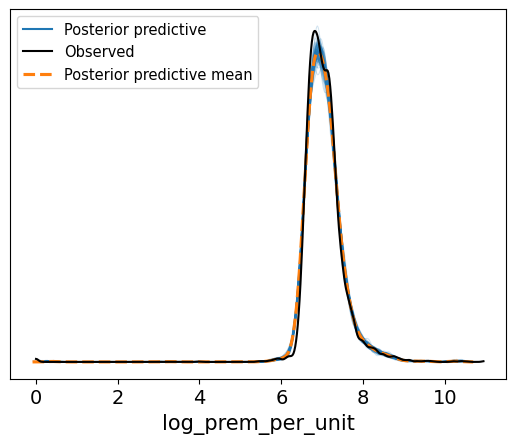

In [26]:
ppc_preds = model.predict(results, kind="response", inplace=False)

az.plot_ppc(ppc_preds, var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [27]:
print("\n" + "=" * 60)
print("Step 4: Checking convergence...")
print("=" * 60)

# Check Rhat and ESS
summary = az.summary(results, var_names=['Intercept', 'yr_scaled'] + climate_financial_vars)
print("\nFixed effects summary:")
print(summary)

# Check for convergence issues
rhat_max = summary['r_hat'].max()
ess_min = summary['ess_bulk'].min()

print(f"\nConvergence diagnostics:")
print(f"  Max R-hat: {rhat_max:.4f} {'' if rhat_max < 1.01 else ''}")
print(f"  Min ESS:   {ess_min:.0f} {'' if ess_min > 400 else ''}")

if rhat_max > 1.01:
    print("\n Warning: Some R-hat > 1.01, consider:")
    print("   - Increasing tune/draws")
    print("   - Checking for problematic parameters")


Step 4: Checking convergence...

Fixed effects summary:
                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept                  6.952  0.032   6.894    7.013      0.001    0.001   
yr_scaled                  0.087  0.010   0.070    0.107      0.000    0.000   
flood_frequency            0.003  0.003  -0.003    0.009      0.000    0.000   
flood_property_damage      0.003  0.003  -0.003    0.009      0.000    0.000   
flood_duration_hours       0.002  0.003  -0.003    0.007      0.000    0.000   
heat_stress_index         -0.024  0.009  -0.041   -0.007      0.000    0.000   
drought_annual_mean_index -0.009  0.005  -0.019    0.001      0.000    0.000   
fire_frequency             0.018  0.012  -0.004    0.040      0.000    0.000   
fire_size                  0.006  0.003  -0.000    0.012      0.000    0.000   
unemployment_rate         -0.005  0.011  -0.025    0.016      0.000    0.000   
prop_rate                 -0.024  0.017  -0.056    0.006      0

### Fit the Bayesian model with only climate variables

In [28]:
climate_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size"
]

financial_vars = [
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

formula_climate = f"""
log_prem_per_unit ~ 
    yr_scaled + 
    {' + '.join(climate_vars)} + 
    (1 | zipcode) + 
    (1 + yr_scaled | county)
"""

model_climate = bmb.Model(formula_climate, data=final_df_bayes)

results_climate = model_climate.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    idata_kwargs={"log_likelihood": True},
    target_accept=0.95
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, yr_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, 1|zipcode_sigma, 1|zipcode_offset, 1|county_sigma, 1|county_offset, yr_scaled|county_sigma, yr_scaled|county_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 265 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='log_prem_per_unit'>

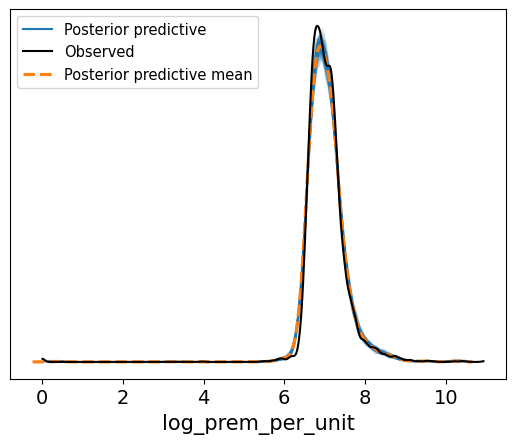

In [29]:
ppc_preds_climate = model_climate.predict(results_climate, kind="response", inplace=False)

az.plot_ppc(ppc_preds_climate, var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [30]:
# Check Rhat and ESS
summary_climate = az.summary(results_climate, var_names=['Intercept', 'yr_scaled'] + climate_vars)
print("\nFixed effects summary:")
print(summary_climate)

# Check for convergence issues
rhat_max = summary_climate['r_hat'].max()
ess_min = summary_climate['ess_bulk'].min()

print(f"\nConvergence diagnostics:")
print(f"  Max R-hat: {rhat_max:.4f} {'' if rhat_max < 1.01 else ''}")
print(f"  Min ESS:   {ess_min:.0f} {'' if ess_min > 400 else ''}")

if rhat_max > 1.01:
    print("\n Warning: Some R-hat > 1.01, consider:")
    print("   - Increasing tune/draws")
    print("   - Checking for problematic parameters")


Fixed effects summary:
                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept                  6.962  0.031   6.902    7.019      0.001    0.001   
yr_scaled                  0.084  0.004   0.077    0.092      0.000    0.000   
flood_frequency            0.003  0.003  -0.003    0.009      0.000    0.000   
flood_property_damage      0.003  0.003  -0.003    0.008      0.000    0.000   
flood_duration_hours       0.002  0.002  -0.002    0.007      0.000    0.000   
heat_stress_index         -0.023  0.009  -0.039   -0.007      0.000    0.000   
drought_annual_mean_index -0.008  0.003  -0.014   -0.003      0.000    0.000   
fire_frequency             0.014  0.010  -0.005    0.032      0.000    0.000   
fire_size                  0.006  0.003  -0.000    0.012      0.000    0.000   

                           ess_bulk  ess_tail  r_hat  
Intercept                     496.0    1039.0    1.0  
yr_scaled                    2244.0    2767.0    1.0  
flood_freq

In [31]:
print("=" * 60)
print("MODEL COMPARISON WITH LOO")
print("=" * 60)

# LOO Comparison
compare_dict = {
    "climate and financial": results,
    "climate": results_climate
}
comparison = az.compare(compare_dict, ic="loo")
print(comparison)

MODEL COMPARISON WITH LOO


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/s

                       rank     elpd_loo        p_loo  elpd_diff    weight  \
climate and financial     0  3063.973765  1458.197669   0.000000  0.660136   
climate                   1  3058.232442  1469.534458   5.741323  0.339864   

                               se       dse  warning scale  
climate and financial  646.691085  0.000000     True   log  
climate                644.873593  9.751655     True   log  


In [34]:
def bayes_r2(idata, y_obs_name, y_true):
    mu = idata.posterior["mu"]   # chain, draw, obs
    y_true = np.asarray(y_true)

    var_fit = mu.var(dim="__obs__")
    var_res = ((y_true[None, None, :] - mu) ** 2).var(dim="__obs__")
    r2 = var_fit / (var_fit + var_res)
    return r2

r2_full = bayes_r2(results, "log_prem_per_unit", final_df_bayes["log_prem_per_unit"].values)
r2_climate = bayes_r2(results_climate, "log_prem_per_unit", final_df_bayes["log_prem_per_unit"].values)

print("Full model Bayesian R²:")
print(r2_full.mean().values)

print("Climate-only Bayesian R²:")
print(r2_climate.mean().values)

Full model Bayesian R²:
0.8417936639479314
Climate-only Bayesian R²:
0.8413658064263636


### EDA for county random slope

EDA: DO WE NEED RANDOM SLOPES?

Data summary:
  ZIP codes: 1902
  Counties: 58
  Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
  Observations: 5553

FITTING INDIVIDUAL TRENDS

Fitting ZIP-level trends...
✅ Fitted trends for 1839 ZIP codes

Fitting county-level trends...
✅ Fitted trends for 58 counties

VARIABILITY IN SLOPES

ZIP-level slopes:
  Mean: 0.081662
  SD: 0.175954
  Min: -6.263398
  Max: 2.091764
  Range: 8.355163

County-level slopes:
  Mean: 0.085541
  SD: 0.029233
  Min: 0.005815
  Max: 0.150637

Test if county slopes differ from 0:
  t-statistic: 22.2851
  p-value: 0.0000
  ✅ Time trends are significant!

Variance in slopes:
  Between-county variance: 0.00085456

✅ Figure saved: random_slope_justification_eda.png

STATISTICAL EVIDENCE FOR RANDOM SLOPES

1. Variance decomposition:
   Between-county variance in slopes: 0.00085456
   Mean slope: 0.085541
   SD of slopes: 0.029233
   Coefficient of variation: 0.34
   ⚠️ Moderate heterogeneity in slopes (CV > 0.25)
 

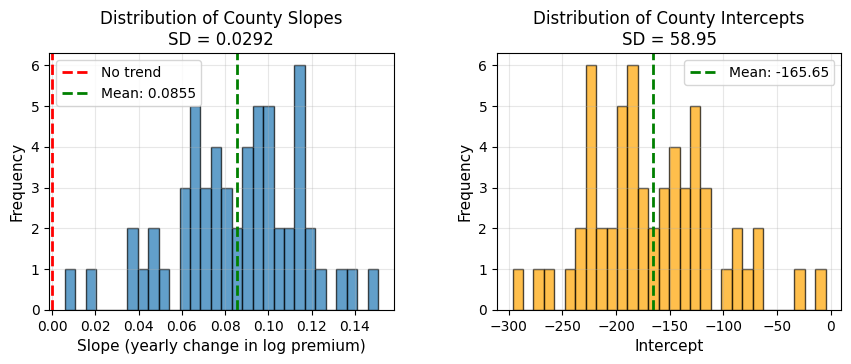

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

print("=" * 60)
print("EDA: DO WE NEED RANDOM SLOPES?")
print("=" * 60)

# Prepare the data
df_eda = final_df_bayes.copy()
df_eda = df_eda.dropna(subset=['log_prem_per_unit', 'yr', 'zipcode', 'county_fips5'])

print(f"\nData summary:")
print(f"  ZIP codes: {df_eda['zipcode'].nunique()}")
print(f"  Counties: {df_eda['county_fips5'].nunique()}")
print(f"  Years: {sorted(df_eda['yr'].unique())}")
print(f"  Observations: {len(df_eda)}")

# Prepare linear fit for each zipcode and county

print("\n" + "=" * 60)
print("FITTING INDIVIDUAL TRENDS")
print("=" * 60)

def fit_group_trend(group_df):
    if len(group_df) < 2:
        return None
    
    X = group_df['yr'].values.reshape(-1, 1)
    y = group_df['log_prem_per_unit'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    return {
        'intercept': model.intercept_,
        'slope': model.coef_[0],
        'n_obs': len(group_df),
        'mean_prem': y.mean(),
        'yr_min': X.min(),
        'yr_max': X.max()
    }

# ZIP-level trends
print("\nFitting ZIP-level trends...")
zip_trends = []
for zipcode in df_eda['zipcode'].unique():
    zip_df = df_eda[df_eda['zipcode'] == zipcode]
    trend = fit_group_trend(zip_df)
    if trend:
        trend['zipcode'] = zipcode
        zip_trends.append(trend)

zip_trends_df = pd.DataFrame(zip_trends)
print(f"Fitted trends for {len(zip_trends_df)} ZIP codes")

# County-level trends
print("\nFitting county-level trends...")
county_trends = []
for county in df_eda['county_fips5'].unique():
    county_df = df_eda[df_eda['county_fips5'] == county]
    trend = fit_group_trend(county_df)
    if trend:
        trend['county_fips5'] = county
        county_trends.append(trend)

county_trends_df = pd.DataFrame(county_trends)
print(f"Fitted trends for {len(county_trends_df)} counties")

print("\n" + "=" * 60)
print("VARIABILITY IN SLOPES")
print("=" * 60)

print("\nZIP-level slopes:")
print(f"  Mean: {zip_trends_df['slope'].mean():.6f}")
print(f"  SD: {zip_trends_df['slope'].std():.6f}")
print(f"  Min: {zip_trends_df['slope'].min():.6f}")
print(f"  Max: {zip_trends_df['slope'].max():.6f}")
print(f"  Range: {zip_trends_df['slope'].max() - zip_trends_df['slope'].min():.6f}")

print("\nCounty-level slopes:")
print(f"  Mean: {county_trends_df['slope'].mean():.6f}")
print(f"  SD: {county_trends_df['slope'].std():.6f}")
print(f"  Min: {county_trends_df['slope'].min():.6f}")
print(f"  Max: {county_trends_df['slope'].max():.6f}")

from scipy import stats

# Test if slopes differ from 0
t_stat, p_val = stats.ttest_1samp(county_trends_df['slope'], 0)
print(f"\nTest if county slopes differ from 0:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_val:.4f}")

if p_val < 0.05:
    print("  Time trends are significant!")
else:
    print("  Time trends not significant")

# Test variance in slopes
print(f"\nVariance in slopes:")
print(f"  Between-county variance: {county_trends_df['slope'].var():.8f}")

In [ ]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)


# Distribution of Slopes 
ax4 = fig.add_subplot(gs[1, 1])

ax4.hist(county_trends_df['slope'], bins=30, edgecolor='black', alpha=0.7)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='No trend')
ax4.axvline(county_trends_df['slope'].mean(), color='green', 
            linestyle='--', linewidth=2, label=f"Mean: {county_trends_df['slope'].mean():.4f}")
ax4.set_xlabel('Slope (yearly change in log premium)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title(f'Distribution of County Slopes\nSD = {county_trends_df["slope"].std():.4f}', 
              fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

# Distribution of Intercepts
ax5 = fig.add_subplot(gs[1, 2])

ax5.hist(county_trends_df['intercept'], bins=30, edgecolor='black', 
         alpha=0.7, color='orange')
ax5.axvline(county_trends_df['intercept'].mean(), color='green', 
            linestyle='--', linewidth=2, label=f"Mean: {county_trends_df['intercept'].mean():.2f}")
ax5.set_xlabel('Intercept', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title(f'Distribution of County Intercepts\nSD = {county_trends_df["intercept"].std():.2f}', 
              fontsize=12)
ax5.legend()
ax5.grid(alpha=0.3)


print("Figure saved: random_slope_justification_eda.png")

EDA: COUNTY TIME TRENDS
Data: 5553 observations
Counties: 58
Years: [np.int64(2018), np.int64(2019), np.int64(2020)]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


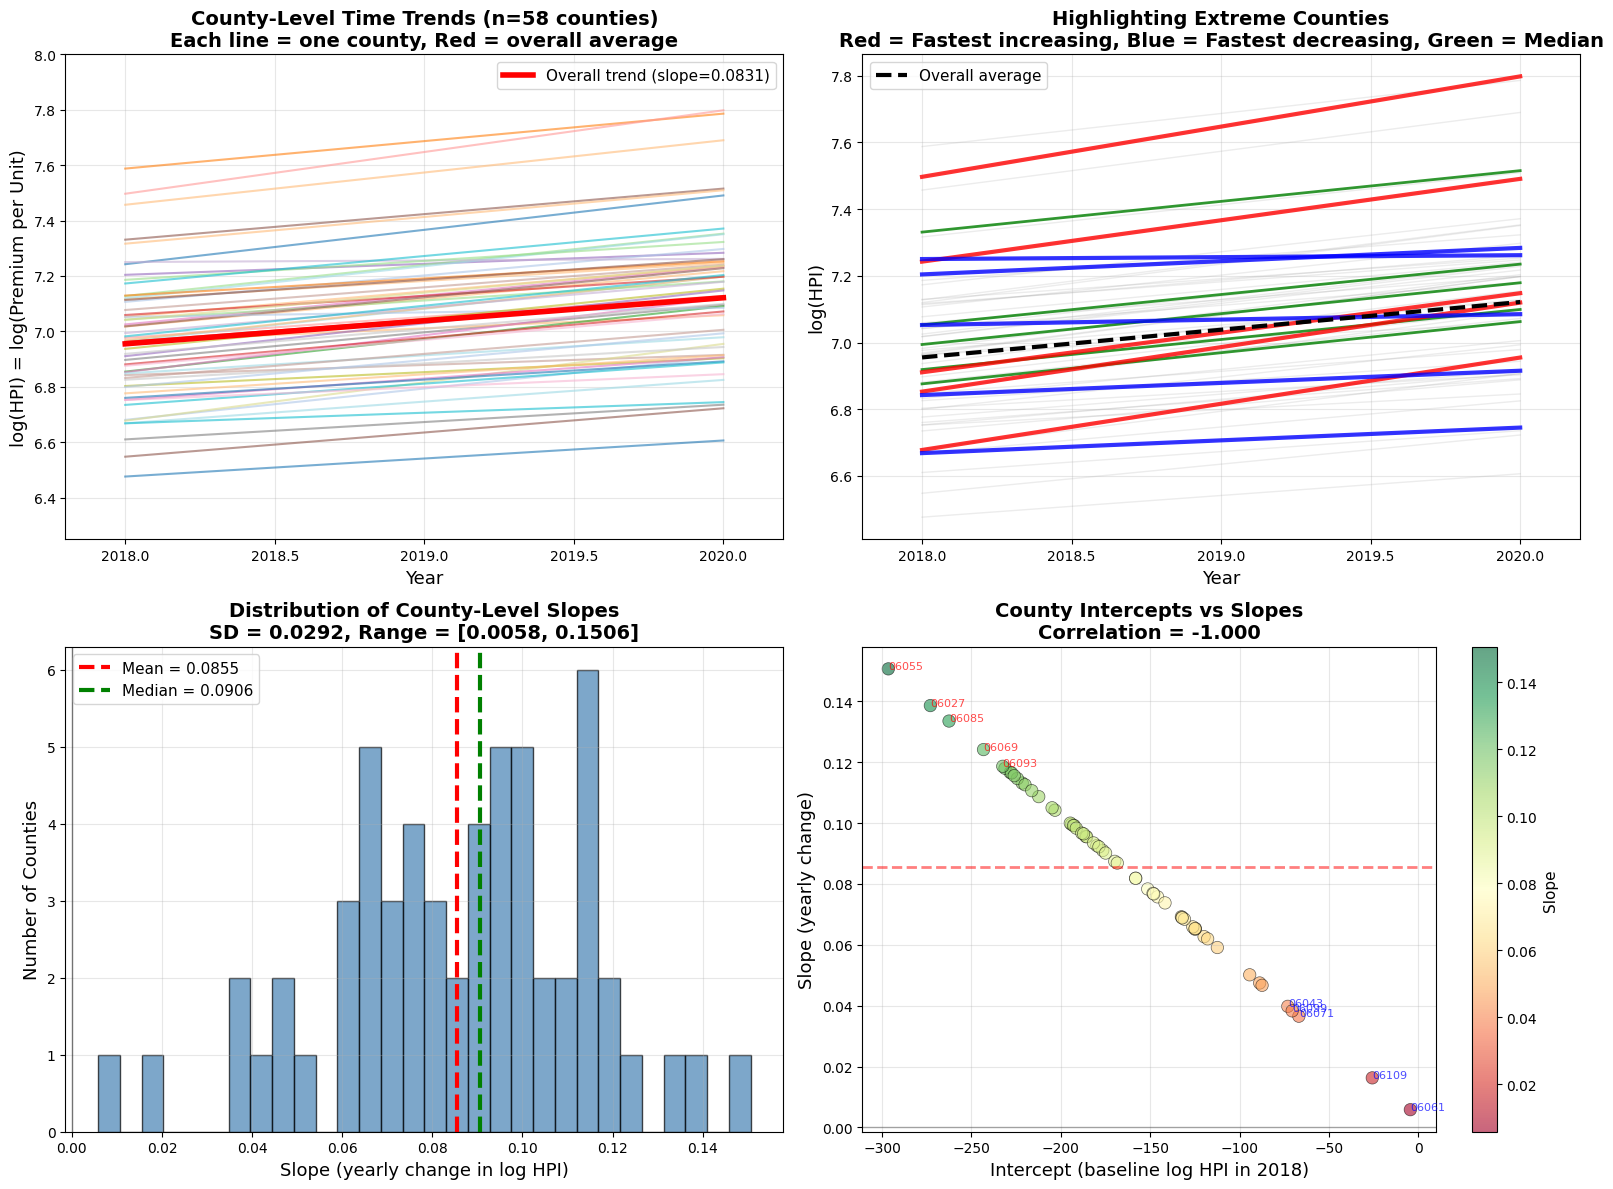


✅ Figure saved: county_time_trends_eda.png


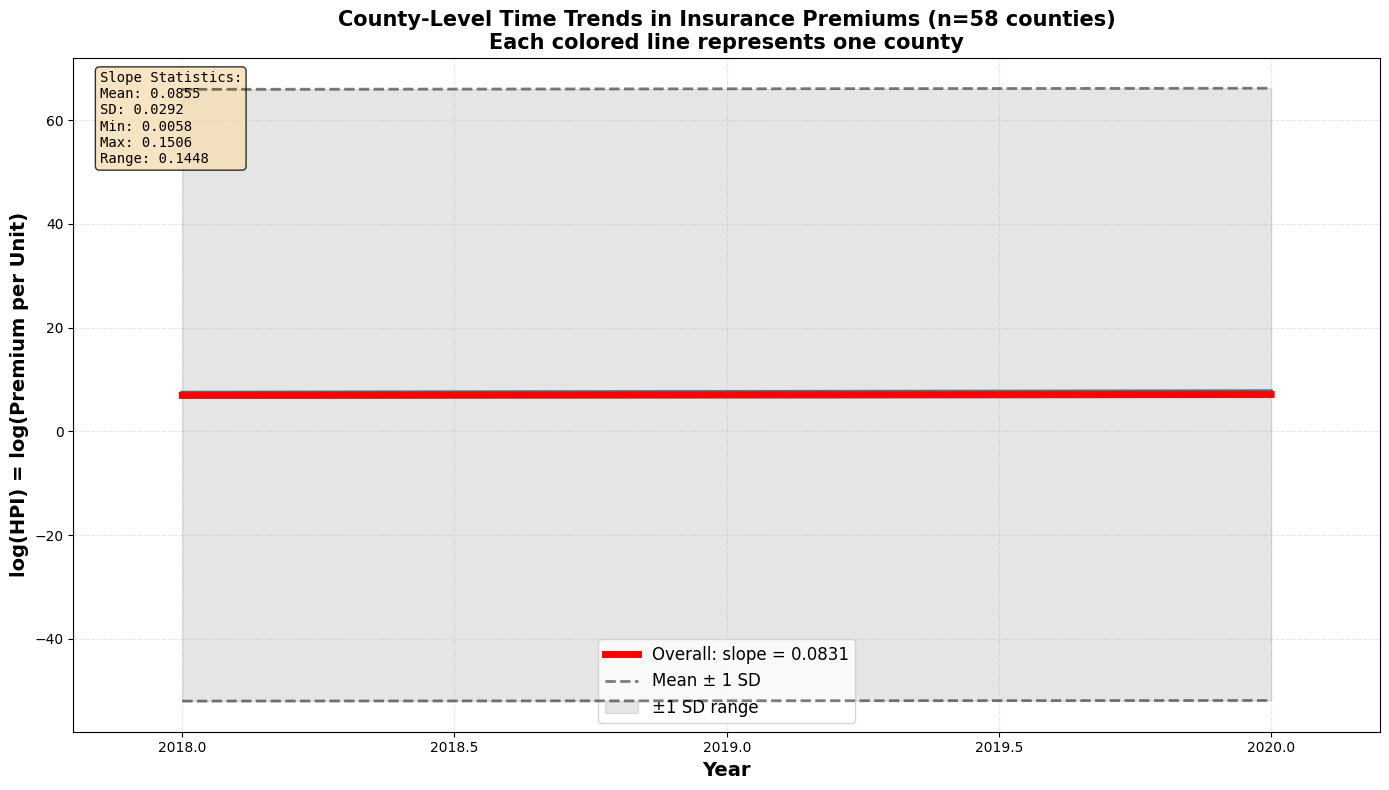

✅ Clean version saved: county_time_trends_clean.png

COUNTY SLOPE STATISTICS

Descriptive Statistics:
count    58.000000
mean      0.085541
std       0.029233
min       0.005815
25%       0.066504
50%       0.090557
75%       0.104804
max       0.150637
Name: slope, dtype: float64

Extreme Counties:

Top 5 Fastest Increasing:
county    slope
 06055 0.150637
 06027 0.138579
 06085 0.133492
 06069 0.124125
 06093 0.118629

Top 5 Fastest Decreasing:
county    slope
 06061 0.005815
 06109 0.016269
 06071 0.036522
 06099 0.038282
 06043 0.039766

Test H₀: slope = 0
  t-statistic: 22.2851
  p-value: 8.0460e-30
  ✅ Slopes are highly significantly different from 0

Variability in slopes:
  Coefficient of variation: 0.342
  ✅ Substantial heterogeneity (CV > 0.3)
  → Random slopes are justified

CONCLUSION

Based on the EDA:
1. There IS variability in county-level slopes
   - SD of slopes = 0.0292
   - Range = [0.0058, 0.1506]
   
2. Average trend is 0.0855 log-units/year
   - Or approximately 8

: 

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

print("=" * 60)
print("EDA: COUNTY TIME TRENDS")
print("=" * 60)

# Prepare the data
df_plot = final_df_bayes.dropna(subset=['log_prem_per_unit', 'yr', 'county']).copy()

print(f"Data: {len(df_plot)} observations")
print(f"Counties: {df_plot['county'].nunique()}")
print(f"Years: {sorted(df_plot['yr'].unique())}")

# All counties on one plot

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Raw data + trend lines (all counties)
ax = axes[0, 0]

counties = df_plot['county'].unique()
n_counties = len(counties)

np.random.seed(42)
for county in counties:
    county_df = df_plot[df_plot['county'] == county]
    
    if len(county_df) >= 2:
        X = county_df['yr'].values.reshape(-1, 1)
        y = county_df['log_prem_per_unit'].values
        
        model = LinearRegression()
        model.fit(X, y)
        
        years = np.array([2018, 2020])
        fitted = model.predict(years.reshape(-1, 1))
        
        color = plt.cm.tab20(np.random.rand())
        ax.plot(years, fitted, alpha=0.6, linewidth=1.5, color=color)

overall_model = LinearRegression()
overall_model.fit(df_plot[['yr']], df_plot['log_prem_per_unit'])
years_overall = np.array([2018, 2020])
overall_fitted = overall_model.predict(years_overall.reshape(-1, 1))
ax.plot(years_overall, overall_fitted, 'r-', linewidth=4, 
       label=f'Overall trend (slope={overall_model.coef_[0]:.4f})', 
       zorder=100)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('log(HPI) = log(Premium per Unit)', fontsize=13)
ax.set_title(f'County-Level Time Trends (n={n_counties} counties)\n' + 
            'Each line = one county, Red = overall average',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([2017.8, 2020.2])
ax.set_ylim([6.25, 8]) 

# Plot for extreme counties
ax = axes[0, 1]

# Calculate slope for each county
county_slopes = []
for county in counties:
    county_df = df_plot[df_plot['county'] == county]
    if len(county_df) >= 2:
        X = county_df['yr'].values.reshape(-1, 1)
        y = county_df['log_prem_per_unit'].values
        model = LinearRegression()
        model.fit(X, y)
        county_slopes.append({
            'county': county,
            'slope': model.coef_[0],
            'intercept': model.intercept_
        })

county_slopes_df = pd.DataFrame(county_slopes)

top_5_increasing = county_slopes_df.nlargest(5, 'slope')
top_5_decreasing = county_slopes_df.nsmallest(5, 'slope')
median_counties = county_slopes_df.iloc[
    (county_slopes_df['slope'] - county_slopes_df['slope'].median()).abs().argsort()[:5]
]

for county in counties:
    county_df = df_plot[df_plot['county'] == county]
    if len(county_df) >= 2:
        X = county_df['yr'].values.reshape(-1, 1)
        y = county_df['log_prem_per_unit'].values
        model = LinearRegression()
        model.fit(X, y)
        years = np.array([2018, 2020])
        fitted = model.predict(years.reshape(-1, 1))
        ax.plot(years, fitted, alpha=0.15, linewidth=1, color='gray', zorder=1)

for idx, row in top_5_increasing.iterrows():
    county_df = df_plot[df_plot['county'] == row['county']]
    years = np.array([2018, 2020])
    fitted = row['intercept'] + row['slope'] * years
    ax.plot(years, fitted, linewidth=3, color='red', alpha=0.8, zorder=3)

for idx, row in top_5_decreasing.iterrows():
    county_df = df_plot[df_plot['county'] == row['county']]
    years = np.array([2018, 2020])
    fitted = row['intercept'] + row['slope'] * years
    ax.plot(years, fitted, linewidth=3, color='blue', alpha=0.8, zorder=3)

for idx, row in median_counties.iterrows():
    county_df = df_plot[df_plot['county'] == row['county']]
    years = np.array([2018, 2020])
    fitted = row['intercept'] + row['slope'] * years
    ax.plot(years, fitted, linewidth=2, color='green', alpha=0.8, zorder=2)

ax.plot(years_overall, overall_fitted, 'k--', linewidth=3, 
       label='Overall average', zorder=4)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('log(HPI)', fontsize=13)
ax.set_title('Highlighting Extreme Counties\n' + 
            'Red = Fastest increasing, Blue = Fastest decreasing, Green = Median',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([2017.8, 2020.2])

# Plot for slope distribution
ax = axes[1, 0]

ax.hist(county_slopes_df['slope'], bins=30, edgecolor='black', 
       alpha=0.7, color='steelblue')
ax.axvline(county_slopes_df['slope'].mean(), color='red', 
          linestyle='--', linewidth=3,
          label=f"Mean = {county_slopes_df['slope'].mean():.4f}")
ax.axvline(county_slopes_df['slope'].median(), color='green',
          linestyle='--', linewidth=3,
          label=f"Median = {county_slopes_df['slope'].median():.4f}")
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('Slope (yearly change in log HPI)', fontsize=13)
ax.set_ylabel('Number of Counties', fontsize=13)
ax.set_title(f'Distribution of County-Level Slopes\n' + 
            f'SD = {county_slopes_df["slope"].std():.4f}, Range = [{county_slopes_df["slope"].min():.4f}, {county_slopes_df["slope"].max():.4f}]',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Slope vs Intercept scatter
ax = axes[1, 1]

scatter = ax.scatter(county_slopes_df['intercept'], 
                    county_slopes_df['slope'],
                    alpha=0.6, s=80, c=county_slopes_df['slope'],
                    cmap='RdYlGn', edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Slope', fontsize=11)

ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.axhline(county_slopes_df['slope'].mean(), color='red', 
          linestyle='--', linewidth=2, alpha=0.5)

for idx, row in top_5_increasing.iterrows():
    ax.annotate(f"{str(row['county'])[:5]}", 
               (row['intercept'], row['slope']),
               fontsize=8, alpha=0.7, color='red')

for idx, row in top_5_decreasing.iterrows():
    ax.annotate(f"{str(row['county'])[:5]}", 
               (row['intercept'], row['slope']),
               fontsize=8, alpha=0.7, color='blue')

ax.set_xlabel('Intercept (baseline log HPI in 2018)', fontsize=13)
ax.set_ylabel('Slope (yearly change)', fontsize=13)
ax.set_title('County Intercepts vs Slopes\n' + 
            f'Correlation = {county_slopes_df[["intercept", "slope"]].corr().iloc[0,1]:.3f}',
            fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Forecast 2021-2023

In [18]:
# Extrapolate predictors

print("\n" + "=" * 60)
print("EXTRAPOLATING PREDICTORS")
print("=" * 60)

def extrapolate_predictors(df, vars_to_extrapolate, target_years):
    """For each zipcode, linearly extrapolate predictors to target years."""
    rows = []

    for zipcode, df_zip in df.groupby("zipcode"):
        df_zip = df_zip.sort_values("yr")
        row = {"zipcode": zipcode}

        # keep county for this zipcode
        row["county"] = df_zip["county"].iloc[0]

        years = df_zip["yr"].values

        for var in vars_to_extrapolate:
            values = df_zip[var].values

            # if too few points, fallback to last observed value
            if len(df_zip) < 2 or np.all(values == values[0]):
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = values[-1]
            else:
                slope, intercept = np.polyfit(years, values, 1)
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = slope * target_year + intercept

        rows.append(row)

    return pd.DataFrame(rows)

target_years = [2021, 2022, 2023]

future_predictors = extrapolate_predictors(
    final_df_bayes,
    climate_financial_vars,
    target_years
)

print(f"Extrapolated predictors for {len(future_predictors)} zipcodes")

# Predict for 2021-2023

print("\n" + "=" * 60)
print("FORECASTING 2021-2023")
print("=" * 60)

forecasts_all_years = []

for year in target_years:
    print(f"\nForecasting {year}...")

    # construct future data
    forecast_data = future_predictors[["zipcode", "county"]].copy()
    forecast_data["yr_scaled"] = year - year_min

    for var in climate_financial_vars:
        forecast_data[var] = future_predictors[f"{var}_{year}"].values

    # make sure types match training data
    forecast_data["zipcode"] = forecast_data["zipcode"].astype(str)
    forecast_data["county"] = forecast_data["county"].astype(str)

    # generate posterior predictive samples
    idata_pred = model.predict(
        results,
        data=forecast_data,
        kind="response",
        inplace=False
    )

    preds_log = idata_pred.posterior_predictive["log_prem_per_unit"]
    # dims usually: chain, draw, __obs__
    
    # inverse transform on each draw first
    preds_original = np.expm1(preds_log)

    forecast_data["predicted_mean"] = preds_original.mean(
        dim=["chain", "draw"]
    ).values

    forecast_data["predicted_lower"] = preds_original.quantile(
        0.025, dim=["chain", "draw"]
    ).values

    forecast_data["predicted_upper"] = preds_original.quantile(
        0.975, dim=["chain", "draw"]
    ).values

    forecast_data["year"] = year
    forecasts_all_years.append(forecast_data)

final_forecasts = pd.concat(forecasts_all_years, ignore_index=True)

print("\nForecasts completed!")
print(final_forecasts.head())


EXTRAPOLATING PREDICTORS
Extrapolated predictors for 1902 zipcodes

FORECASTING 2021-2023

Forecasting 2021...

Forecasting 2022...

Forecasting 2023...

Forecasts completed!
  zipcode county  yr_scaled  flood_frequency  flood_property_damage  \
0   90001  06037          3        -0.554992               -0.13883   
1   90002  06037          3        -0.554992               -0.13883   
2   90003  06037          3        -0.554992               -0.13883   
3   90004  06037          3        -0.554992               -0.13883   
4   90005  06037          3        -0.554992               -0.13883   

   flood_duration_hours  heat_stress_index  drought_annual_mean_index  \
0             -0.422891          -0.220303                   2.516706   
1             -0.422891          -0.220303                   2.516706   
2             -0.422891          -0.220303                   2.516706   
3             -0.422891          -0.220303                   2.516706   
4             -0.422891         

In [39]:
# Read data from California wildfire insurance
wildfire_insurance = pd.read_excel("../../02_processed_data/Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx", 
sheet_name="Export_all", header=2)

# Subset data from 2021-2023, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_21_23 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2021, 2023))]

# Keep the column of interest
wildfire_insurance_21_23 = wildfire_insurance_21_23[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [40]:
wildfire_insurance_21_23.head()

,Calendar Year,ZIP Code,Earned Prem,Earned Exp
18,2021,90001,1629265,1976
19,2022,90001,1828773,2063
20,2023,90001,1998381,2109
60,2021,90002,2281854,2781
61,2022,90002,2583205,2922


In [41]:
# Force the zipcode to be a string
wildfire_insurance_21_23['ZIP Code'] = wildfire_insurance_21_23['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted_21_23 = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main_21_23 = crosswalk_ca_sorted_21_23.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip_21_23 = wildfire_insurance_21_23.merge(
    crosswalk_main_21_23[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_24233/4118842553.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [42]:
# Create premium per unit to show average earned premium for each housing unit
wildfire_zip_21_23 = wildfire_zip_21_23[wildfire_zip_21_23['Earned Exp'] > 0]
wildfire_zip_21_23['prem_per_unit'] = wildfire_zip_21_23['Earned Prem'] / wildfire_zip_21_23['Earned Exp']

In [43]:
wildfire_zip_21_23.head(4)

,Calendar Year,ZIP Code,Earned Prem,Earned Exp,ZIP,COUNTY,prem_per_unit
0,2021,90001,1629265,1976,90001,06037,824.526822
1,2022,90001,1828773,2063,90001,06037,886.462918
2,2023,90001,1998381,2109,90001,06037,947.549075
3,2021,90002,2281854,2781,90002,06037,820.515642


In [44]:
print("\n" + "=" * 60)
print("LOADING ACTUAL 2021-2023 DATA")
print("=" * 60)

actual_df = wildfire_zip_21_23.copy() 

actual_df = actual_df.rename(columns={
    'ZIP Code': 'zipcode', 
    'Calendar Year': 'year'
})

print(f"Actual data shape: {actual_df.shape}")
print(f"Years: {sorted(actual_df['year'].unique())}")
print(f"ZIP codes: {actual_df['zipcode'].nunique()}")

if 'prem_per_unit' not in actual_df.columns:
    print("Warning: 'prem_per_unit' column not found!")
    print(f"Available columns: {actual_df.columns.tolist()}")
else:
    print("Premium column found")


LOADING ACTUAL 2021-2023 DATA
Actual data shape: (5516, 7)
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]
ZIP codes: 1874
✅ Premium column found


In [45]:
print("\n" + "=" * 60)
print("MERGING PREDICTIONS WITH ACTUAL DATA")
print("=" * 60)

comparison_df = final_forecasts.merge(
    actual_df[['zipcode', 'year', 'prem_per_unit']],
    on=['zipcode', 'year'],
    how='inner', 
    suffixes=('_forecast', '_actual')
)

print(f"Merged data shape: {comparison_df.shape}")
print(f"ZIP codes: {comparison_df['zipcode'].nunique()}")
print(f"Years: {sorted(comparison_df['year'].unique())}")

# rename the columns
comparison_df = comparison_df.rename(columns={
    'predicted_mean': 'forecast',
    'prem_per_unit': 'actual'
})

print(comparison_df[['zipcode', 'year', 'actual', 'forecast', 'predicted_lower', 'predicted_upper']].head(10))


MERGING PREDICTIONS WITH ACTUAL DATA


NameError: name 'final_forecasts' is not defined

In [26]:
# Calculate prediction errors

print("\n" + "=" * 60)
print("CALCULATING PREDICTION ERRORS")
print("=" * 60)

comparison_df['error'] = comparison_df['forecast'] - comparison_df['actual']
comparison_df['abs_error'] = np.abs(comparison_df['error'])
comparison_df['pct_error'] = (comparison_df['error'] / comparison_df['actual']) * 100
comparison_df['abs_pct_error'] = np.abs(comparison_df['pct_error'])

comparison_df['in_ci'] = (
    (comparison_df['actual'] >= comparison_df['predicted_lower']) & 
    (comparison_df['actual'] <= comparison_df['predicted_upper'])
)

print("Error metrics calculated")


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 60)
print("OVERALL FORECAST ACCURACY (2021-2023)")
print("=" * 60)

y_actual = comparison_df['actual'].values
y_forecast = comparison_df['forecast'].values

rmse = np.sqrt(mean_squared_error(y_actual, y_forecast))
mae = mean_absolute_error(y_actual, y_forecast)
mape = comparison_df['abs_pct_error'].mean()
r2 = r2_score(y_actual, y_forecast)
coverage = comparison_df['in_ci'].mean() * 100

print(f"Sample size: {len(comparison_df)}")
print(f"\nAccuracy Metrics:")
print(f"  R²:                  {r2:.4f}")
print(f"  RMSE:                ${rmse:.2f}")
print(f"  MAE:                 ${mae:.2f}")
print(f"  MAPE:                {mape:.2f}%")
print(f"  95% CI Coverage:     {coverage:.1f}% (ideal: 95%)")

print(f"\nError Distribution:")
print(f"  Mean error:          ${comparison_df['error'].mean():.2f}")
print(f"  Median error:        ${comparison_df['error'].median():.2f}")
print(f"  Std of errors:       ${comparison_df['error'].std():.2f}")


CALCULATING PREDICTION ERRORS
✅ Error metrics calculated

OVERALL FORECAST ACCURACY (2021-2023)
Sample size: 5395

Accuracy Metrics:
  R²:                  0.4626
  RMSE:                $2509.27
  MAE:                 $242.26
  MAPE:                14.59%
  95% CI Coverage:     95.1% (ideal: 95%)

Error Distribution:
  Mean error:          $-141.87
  Median error:        $-25.61
  Std of errors:       $2505.49


In [27]:
# Accuracy by year
print("\n" + "=" * 60)
print("ACCURACY BY YEAR")
print("=" * 60)

for year in sorted(comparison_df['year'].unique()):
    year_df = comparison_df[comparison_df['year'] == year]
    
    y_act = year_df['actual'].values
    y_for = year_df['forecast'].values
    
    r2_year = r2_score(y_act, y_for)
    rmse_year = np.sqrt(mean_squared_error(y_act, y_for))
    mape_year = year_df['abs_pct_error'].mean()
    coverage_year = year_df['in_ci'].mean() * 100
    
    print(f"\n{year} (n={len(year_df)}):")
    print(f"  R²:              {r2_year:.4f}")
    print(f"  RMSE:            ${rmse_year:.2f}")
    print(f"  MAPE:            {mape_year:.2f}%")
    print(f"  95% CI Coverage: {coverage_year:.1f}%")


ACCURACY BY YEAR

2021 (n=1814):
  R²:              0.7704
  RMSE:            $1003.01
  MAPE:            6.80%
  95% CI Coverage: 97.8%

2022 (n=1802):
  R²:              0.6584
  RMSE:            $1347.81
  MAPE:            25.85%
  95% CI Coverage: 95.1%

2023 (n=1779):
  R²:              0.3654
  RMSE:            $4028.49
  MAPE:            11.13%
  95% CI Coverage: 92.2%


: 